
<p align='center'> <br> ▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄  </p>
<h2 align="center"> Predicting Fare Amount and Taxi Provider (Refactored) </h2>
<p align="center">its-very-berry-dark</p>
<div>
    <p align="center"> Summary: <br> 
    A personal project restructured from the original file: <i>taxi_prediction_original_2024</i> </b> <br>
</p><br>
</div>

<p align='center'>▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄  </p>

***

#### <span style="color:Orange;">  Table of Contents: </span>

I. Problem Statement and Motivation

II. Data Preparation

III. Exploratory Data Analysis

IV. Feature Importance

V. Machine Learning

VI. Deep Learning
  
VII. Result and discussion

VIII. Conclusion and Recommendations

***


<p><br></p>

<h3>  I. Problem Statement and Motivation </h3>

For a big dataset, particularly with tens of millions of rows, there is inevitability that the data input would have issues whether it's redundant entries, impossible-in-real-life values, etc. This project intends to explore more about the cleaning stage, then perform brief EDA. After the analysis, I'll be proceeding to feature importance stage, then training machine learning and deep learning models. Furthermore, same with the motivation of the original project, I intend to enhance the efficiency and accuracy of fare prediction in this project. This is essentially important since having robust predictive models can streamline operational processes and become a guide for passengers in budgeting their trips, etc. Overall, by leveraging machine learning and deep learning techniques, this project aims to address real-world challenges in the taxi industry.
<p><br><br></p>

***

Importing Modules and Initiliazing a Class

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow import keras

from datetime import datetime
from datetime import timedelta

plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 40)   # displays max columns of the DataFrame 
color_pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
# for print content visualizations
class colors:
    GREEN = '\033[92m'
    RED = '\033[91m'
    END = '\033[0m'


## <span style="color:Orange;"> IV. Data Preparation </span>


For faster handling of the million rows of data, the chunking method is utilized. The provider categories (`Provider Name`) with less than 100k trip records are removed (five taxi providers specifically) as they were deemed insufficient for running the models. At the end, the filtered data in the list are concatenated together and transformed into a DataFrame format.

In [3]:
# Filtering out rows not included in the provider_counts list
path = "../data/taxi_final.csv"       # replace the path if the taxi_final.csv is in another folder

data_chunks = []
chunksize = 500000       # Specify chunksize (number of rows to read at a time)

print("Scanning for major taxi providers...")
provider_counts = pd.Series(dtype='int')

# Read ONLY the ProviderName column in chunks to save memory
for chunk in pd.read_csv(path, chunksize=chunksize, usecols=['PROVIDER NAME']):
    # Tally up the counts and add them to our running total
    provider_counts = provider_counts.add(chunk['PROVIDER NAME'].value_counts(), fill_value=0)

# Keeping only providers with more than 100,000 rides
valid_providers = provider_counts[provider_counts > 150000].index.tolist()
print(f"Keeping {len(valid_providers)} major providers out of {len(provider_counts)} total.")

Scanning for major taxi providers...
Keeping 9 major providers out of 14 total.


In [4]:
print("\nProcessing and sampling the full dataset...")
sampled_chunks = []

for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False):
    
    # Filter out the rare providers 
    filtered_chunk = chunk[chunk['PROVIDER NAME'].isin(valid_providers)]
    
    # Take a random 50% sample of the surviving rows
    sample = filtered_chunk.sample(frac=0.5, random_state=42)
    
    sampled_chunks.append(sample)

# Finally, glue all the tiny 5% chunks together into one master DataFrame
initial_df = pd.concat(sampled_chunks, ignore_index=True)

print(f"\nSuccess! Final sampled dataset size: " + colors.GREEN + f"{len(initial_df)} " + colors.END + "rows.")


Processing and sampling the full dataset...

Success! Final sampled dataset size: 5890155 rows.


Because this project involved multi-task learning (predicting both continuous Fare Price and categorical Provider Name), I implemented class balancing via under-sampling. This prevented the classifier from defaulting to the majority class (e.g. CMT), ensuring the neural network learned the true distinct feature profiles of minority providers.

In [5]:
#renaming the column with an inconsistent structure for better reading
initial_df.rename(columns={'PROVIDER NAME': 'ProviderName', 'Milage': 'Mileage'}, inplace=True)  

In [6]:
initial_df.head(2)

,Type,ProviderName,StartDateTime,DateCreated,ID,ExternalID,FareAmount,GratuityAmount,SurchargeAmount,ExtraFareAmount,TollAmount,TotalAmount,PaymentType,StartDateTime.1,EndDateTime,OriginStreetNumber,OriginStreetName,OriginCity,OriginState,OriginZip,OriginLatitude,OriginLongitude,DestinationStreetNumber,DestinationStreetName,DestinationCity,DestinationState,DestinationZip,DestinationLatitude,DestinationLongitude,Mileage,Duration,Unnamed: 31
0,1.0,CMT,2017-12-22 22:57:29.4600000 +00:00,2017-12-23 21:30:08.8733333 +00:00,A188__61272__2017-12-23T21:30:08.873_36370745,36370745,11.35,3.15,0.25,1.00,0.0,15.75,1.0,2017-12-22 22:57:29.4600000 +00:00,2017-12-22 23:08:52.8100000 +00:00,NaN,1600 Nw I St,Washington,DC,20006,38.90130,-77.03681,NaN,3620 Nw 16th St,Washington,DC,20010,38.93572,-77.03645,3.00,11.0,NaN
1,5.0,Yellow Cab,2017-12-14 07:09:36.0000000 +00:00,2017-12-14 08:02:50.1533333 +00:00,G671__77581__2017-12-14T08:02:50.153_36324214,36324214,25.12,0.00,0.25,3.25,0.0,48.62,2.0,2017-12-14 07:09:36.0000000 +00:00,2017-12-14 08:02:49.0000000 +00:00,NaN,"820 CHESAPEAKE STREET SOUTHEAST , WASHINGTON, ...",NaN,NaN,20032,38.82938,-76.99247,NaN,"2412 FRANKLIN STREET NORTHEAST, WASHINGTON, 20018",NaN,NaN,20018,38.92621,-76.97138,12.03,53.0,NaN


### Duplicate Data 
Compared to the Unique IDs present on the original project, the current work has no duplicated instances of taxi trips.

In [6]:
# counts the number of duplicated rows
print(f"Number of duplicated unique IDs: " + colors.GREEN + f"{initial_df.duplicated(subset=['ID']).sum()}" + colors.END)

Number of duplicated unique IDs: 13


In [8]:
initial_df.loc[initial_df.duplicated(subset=['ID'])]   

,Type,ProviderName,StartDateTime,DateCreated,ID,ExternalID,FareAmount,GratuityAmount,SurchargeAmount,ExtraFareAmount,TollAmount,TotalAmount,PaymentType,StartDateTime.1,EndDateTime,OriginStreetNumber,OriginStreetName,OriginCity,OriginState,OriginZip,OriginLatitude,OriginLongitude,DestinationStreetNumber,DestinationStreetName,DestinationCity,DestinationState,DestinationZip,DestinationLatitude,DestinationLongitude,Mileage,Duration,Unnamed: 31
2106218,1,UVC,2017-02-01 00:00:00.0000000 +00:00,2017-02-01 00:16:43.7633333 +00:00,G836__74262__2017-02-01T00:16:43.763_27245853,27245853,6.22,1.00,0.25,0.00,0.0,7.47,1.0,2017-02-01 00:00:00.0000000 +00:00,2017-02-01 00:06:00.0000000 +00:00,NaN,515 15th St Nw,Washington,DC,20004,38.89709,-77.03318,NaN,1201-1207 13th St NW,Washington,DC,20005,38.90588,-77.02958,0.80,6.0,NaN
4413030,1,Transco,2017-06-01 00:00:00.0000000 +00:00,2017-06-02 08:50:36.8200000 +00:00,K805__52078__2017-06-02T08:50:36.820_32169901,32169901,14.32,3.51,0.25,3.00,0.0,21.08,1.0,2017-06-01 00:00:00.0000000 +00:00,2017-06-01 00:12:00.0000000 +00:00,NaN,S Smith Blvd Arlington,NaN,VA,22202.0,38.85187,-77.04321,NaN,1357 16th St Nw,Washington,DC,20036.0,38.90817,-77.03640,4.68,12.0,NaN
4705713,1,Transco,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 15:25:12.3366667 +00:00,M130__91165__2017-07-01T15:25:12.337_33198163,33198163,11.62,0.00,0.25,2.00,0.0,13.87,2.0,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 00:14:00.0000000 +00:00,NaN,4909 7th St Nw,Washington,DC,20011,38.94997,-77.02198,NaN,1181 U St Nw,Washington,DC,20009,38.91709,-77.02786,2.64,14.0,NaN
4719325,1,VeriFone,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 16:02:22.1800000 +00:00,F997__91192__2017-07-01T16:02:22.180_33199349,33199349,7.57,0.00,0.25,0.00,0.0,7.82,2.0,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 00:08:00.0000000 +00:00,NaN,3804 Georgia Ave Nw [Us-29],Washington,DC,20011,38.93764,-77.02455,NaN,1876 Wiltberger St Nw,Washington,DC,20001,38.91523,-77.02092,1.56,8.0,NaN
4793721,1,UVC,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 00:21:34.9233333 +00:00,E357__71929__2017-07-01T00:21:34.923_33184084,33184084,7.57,0.00,0.25,0.00,0.0,7.82,2.0,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 00:06:00.0000000 +00:00,NaN,4301 Military Rd NW,Washington,MD,20015,38.96111,-77.08509,NaN,7315 WAVERLY ST,Bethesda,MD,20814,38.98289,-77.09313,1.60,6.0,NaN
4808461,1,Transco,2017-10-01 00:00:00.0000000 +00:00,2017-10-01 16:26:35.4400000 +00:00,K788__77769__2017-10-01T16:26:35.440_35424846,35424846,10.27,0.00,0.25,0.00,0.0,10.52,2.0,2017-10-01 00:00:00.0000000 +00:00,2017-10-01 00:14:00.0000000 +00:00,NaN,1984 Vermont Ave Nw,Washington,DC,20001,38.91667,-77.02561,NaN,1211 Wisconsin Ave Nw,Washington,DC,20007,38.90546,-77.06281,2.59,14.0,NaN
4818157,1,VeriFone,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 15:32:17.4166667 +00:00,D790__76939__2017-07-01T15:32:17.417_33198525,33198525,12.16,0.00,0.25,3.00,0.0,15.41,1.0,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 00:09:00.0000000 +00:00,NaN,S Smith Blvd Arlington,NaN,VA,22202,38.85232,-77.04338,NaN,2242 I St Nw,Washington,DC,20037,38.90061,-77.04940,3.90,9.0,NaN
4915567,1,Transco,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 16:36:04.9733333 +00:00,D391__77123__2017-07-01T16:36:04.973_33200319,33200319,18.64,5.41,0.25,2.75,0.0,27.05,1.0,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 00:22:00.0000000 +00:00,NaN,Washington,NaN,VA,20001,38.85628,-77.04432,NaN,3377 16th St Nw,Washington,DC,20010,38.93301,-77.03642,5.70,22.0,NaN
5332146,1,DC VIP Cab,2017-04-01 00:00:00.0000000 +00:00,2017-04-02 18:35:58.5200000 +00:00,G494__61405__2017-04-02T18:35:58.520_29839544,29839544,11.08,1.23,0.25,1.00,0.0,13.56,1.0,2017-04-01 00:00:00.0000000 +00:00,2017-04-01 00:16:38.0000000 +00:00,NaN,822 E STREET NW WASHINGTON,WASHINGTON,DC,20004,38.89610,-77.02310,NaN,1231 25th Street Northwest,Washington,DC,20037,38.90680,-77.05320,2.20,17.0,NaN
5362415,1,Transco,2017-04-01 00:00:00.0000000 +00:00,2017-04-02 16:54:58.7200000 +00:00,E986__79570__2017-04

In [7]:
initial_df = initial_df.loc[~initial_df.duplicated(subset=['ID'])].reset_index(drop=True).copy()
print(f"Number of duplicated rows after changes: " + colors.GREEN + f"{initial_df.duplicated(subset=['ID']).sum()}" + colors.END)

Number of duplicated rows after changes: 0


### Null Values and Imputation 
<span style="font-size:larger;"> Both <i> StartDateTime </i> and <i> StartDateTime.1 </i> columns are the same, will remove the 2nd occurrence </span>  
<i> New changes: The duplicated column will not be utilized and the EndDateTime will be removed since there's already a `Duration` column. </i>  
    The DataFrame example below only displays the similarities of the mentioned column as an insight.

In [8]:
df = initial_df.copy()

In [11]:
df[['StartDateTime', 'PaymentType', 'StartDateTime.1', 'EndDateTime']].head(2)

,StartDateTime,PaymentType,StartDateTime.1,EndDateTime
0,2017-12-22 22:57:29.4600000 +00:00,1.0,2017-12-22 22:57:29.4600000 +00:00,2017-12-22 23:08:52.8100000 +00:00
1,2017-12-14 07:09:36.0000000 +00:00,2.0,2017-12-14 07:09:36.0000000 +00:00,2017-12-14 08:02:49.0000000 +00:00


***
 #### Imputation and Null Values
<span style="font-size:larger;"> Duration </span>   
In this dataset, we focused on identifying columns that might be a duplicate of another and determining each of the columns' null value. Since Duration has almost 18k null rows, I've imputed it based on the difference of `StartDateTime` and `EndDateTime` columns. The units used for the mentioned column is in minutes, which is retained.

In [9]:
df['Duration'].isnull().sum()

np.int64(179708)

In [10]:
df['StartDateTime'] = pd.to_datetime(df['StartDateTime'])
df['EndDateTime'] = pd.to_datetime(df['EndDateTime'])

missing_mask = df['Duration'].isna()
# imputing missing values on Duration column 
df.loc[missing_mask, 'Duration'] = (
    df['EndDateTime'] - df['StartDateTime']
).dt.total_seconds() / 60

<span style="font-size:larger;"> Date and Location </span>   

In [11]:
# Converting the datetime-like string column to datetime
# Coerce sets the out of bounds date format of observation into NaT (Non-parseable dates)
# ONLY RUN THIS CELL ONCE
df['StartDateTime'] = pd.to_datetime(df['StartDateTime'], utc=True, errors='coerce')

In [12]:
# Extracting date and time into separate columns
df['Pickup_Hour'] = df['StartDateTime'].dt.hour
df['Pickup_DayoftheWeek'] = df['StartDateTime'].dt.dayofweek

# Changing column dtypes
df['ProviderName'] = df['ProviderName'].astype('category')      # setting ProviderName as a category dtype

For more granularity, the `Pickup_Hour` and `Pickup_DayoftheWeek` is created to observe more insightful patterns. Dropping the listed columns below as they would only create more noise in the dataset (and for efficiency). Will only be using the coordinates columns (`OriginLatitude`, `OriginLongitude`, `'DestinationLatitude`, `DestinationLongitude`) for location. Unique Identifiers will be dropped as well.

In [16]:
df.columns

Index(['Type', 'ProviderName', 'StartDateTime', 'DateCreated', 'ID',
       'ExternalID', 'FareAmount', 'GratuityAmount', 'SurchargeAmount',
       'ExtraFareAmount', 'TollAmount', 'TotalAmount', 'PaymentType',
       'StartDateTime.1', 'EndDateTime', 'OriginStreetNumber',
       'OriginStreetName', 'OriginCity', 'OriginState', 'OriginZip',
       'OriginLatitude', 'OriginLongitude', 'DestinationStreetNumber',
       'DestinationStreetName', 'DestinationCity', 'DestinationState',
       'DestinationZip', 'DestinationLatitude', 'DestinationLongitude',
       'Mileage', 'Duration', 'Unnamed: 31', 'Pickup_Hour',
       'Pickup_DayoftheWeek'],
      dtype='str')

In [13]:
columns_to_drop = [
    'StartDateTime', 'StartDateTime.1', 
    'DateCreated', 'EndDateTime', 
    'OriginStreetNumber', 'DestinationStreetNumber', 
    'OriginStreetName', 'DestinationStreetName',
    'OriginCity', 'DestinationCity',
    'OriginState', 'DestinationState',
    'OriginZip', 'DestinationZip', 'Unnamed: 31',
    'Type', 'ID', 'ExternalID', 'PaymentType'
]

actual_cols_to_drop = [col for col in columns_to_drop if col in df.columns]
print(f"Dropping {len(actual_cols_to_drop)} useless or leaky columns...")
df = df.drop(columns=actual_cols_to_drop)
print(f"Remaining Columns: \n {df.columns}")

Dropping 19 useless or leaky columns...
Remaining Columns: 
 Index(['ProviderName', 'FareAmount', 'GratuityAmount', 'SurchargeAmount',
       'ExtraFareAmount', 'TollAmount', 'TotalAmount', 'OriginLatitude',
       'OriginLongitude', 'DestinationLatitude', 'DestinationLongitude',
       'Mileage', 'Duration', 'Pickup_Hour', 'Pickup_DayoftheWeek'],
      dtype='str')


Since there are many columns with null values, it is necessary to drop indexes with null values for a cleaner data. For columns representing transactions and location, the null rows will be dropped.

In [14]:
df.dropna(subset=['GratuityAmount', 'SurchargeAmount', 'ExtraFareAmount', 'TollAmount',
                  'OriginLatitude', 'OriginLongitude', 'DestinationLatitude',
                  'DestinationLongitude', 'Mileage'], inplace=True)

In [15]:
df.isnull().sum()

ProviderName            0
FareAmount              0
GratuityAmount          0
SurchargeAmount         0
ExtraFareAmount         0
TollAmount              0
TotalAmount             0
OriginLatitude          0
OriginLongitude         0
DestinationLatitude     0
DestinationLongitude    0
Mileage                 0
Duration                0
Pickup_Hour             0
Pickup_DayoftheWeek     0
dtype: int64

### Removing rows that have a negative value on numerical columns (FareAmount, Mileage, Duration)
There are some inconsistent rows that had a negative value for the numerical dtypes column. For more accurate representation of data, the group opted to transform the negative values into positive values, since there might be some error on inputting the data which turned the input values into negative. Additionally, any inconsistent rows will be deleted as well, such as:
- Other numerical values that has 0.0 values
- The <span style="color:blue;"> Duration </span> of a taxi ride being 0.0 but the <span style="color:blue;"> FareAmount </span> is more than <span style="color:blue;"> 0 </span>
- <span style="color:red;"> Mileage </span> that doesn't seem to fit the values with <span style="color:red;"> Duration </span> and <span style="color:red;"> FareAmount </span>, etc.

#### Negative and Zero Values

In [20]:
df.describe()

,FareAmount,GratuityAmount,SurchargeAmount,ExtraFareAmount,TollAmount,TotalAmount,OriginLatitude,OriginLongitude,DestinationLatitude,DestinationLongitude,Mileage,Duration,Pickup_Hour,Pickup_DayoftheWeek
count,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06
mean,1.269852e+01,1.425035e+00,2.487456e-01,6.017132e-01,4.167542e-03,1.507104e+01,3.767141e+01,-7.460700e+01,3.772761e+01,-7.470977e+01,1.536344e+01,7.959284e+02,1.391229e+01,2.819220e+00
std,1.959599e+02,1.122887e+02,9.341773e-02,1.155478e+00,1.362913e+00,2.264633e+02,6.844999e+00,1.345570e+01,6.662063e+00,1.319767e+01,2.812138e+02,1.261438e+05,5.842859e+00,1.851835e+00
min,-1.673500e+02,-4.640000e+00,-9.950000e+01,-5.390000e+02,-1.500000e+00,-5.325300e+02,-7.731294e+01,-7.770300e+02,0.000000e+00,-7.770300e+02,-3.320000e+01,-1.435000e+03,0.000000e+00,0.000000e+00
25%,7.300000e+00,0.000000e+00,2.500000e-01,0.000000e+00,0.000000e+00,8.900000e+00,3.889341e+01,-7.704335e+01,3.889215e+01,-7.704550e+01,1.000000e+00,8.000000e+00,1.000000e+01,1.000000e+00
50%,1.009000e+01,0.000000e+00,2.500000e-01,0.000000e+00,0.000000e+00,1.198000e+01,3.890016e+01,-7.703199e+01,3.890132e+01,-7.703240e+01,2.000000e+00,1.300000e+01,1.500000e+01,3.000000e+00
75%,1.459000e+01,2.000000e+00,2.500000e-01,1.000000e+00,0.000000e+00,1.734000e+01,3.890663e+01,-7.701940e+01,3.891130e+01,-7.701750e+01,3.720000e+00,2.600000e+01,1.800000e+01,4.000000e+00
max,3.489662e+05,1.525250e+05,2.189000e+01,6.960000e+02,3.014000e+03,3.489810e+05,3.006980e+02,1.651319e+02,3.006980e+02,1.651319e+02,4.105985e+05,2.522689e+07,2.300000e+01,6.000000e+00


In [21]:
df.columns

Index(['ProviderName', 'FareAmount', 'GratuityAmount', 'SurchargeAmount',
       'ExtraFareAmount', 'TollAmount', 'TotalAmount', 'OriginLatitude',
       'OriginLongitude', 'DestinationLatitude', 'DestinationLongitude',
       'Mileage', 'Duration', 'Pickup_Hour', 'Pickup_DayoftheWeek'],
      dtype='str')

In [16]:
print(f"Number of rows that has a negative values in Duration Column:    " + colors.GREEN + f"{df.query('Duration < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in Mileage Column:    " + colors.GREEN + f"{df.query('Mileage < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in FareAmount Column: " + colors.GREEN + f"{df.query('FareAmount < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in GratuityAmount Column:    " + colors.GREEN + f"{df.query('GratuityAmount < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in SurchargeAmount Column:    " + colors.GREEN + f"{df.query('SurchargeAmount < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in ExtraFareAmount Column: " + colors.GREEN + f"{df.query('ExtraFareAmount < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in TollAmount Column:    " + colors.GREEN + f"{df.query('TollAmount < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in TotalAmount Column:    " + colors.GREEN + f"{df.query('TotalAmount < 0.0').shape[0]}" + colors.END)


Number of rows that has a negative values in Duration Column:    26
Number of rows that has a negative values in Mileage Column:    255
Number of rows that has a negative values in FareAmount Column: 1563
Number of rows that has a negative values in GratuityAmount Column:    46
Number of rows that has a negative values in SurchargeAmount Column:    1277
Number of rows that has a negative values in ExtraFareAmount Column: 5380
Number of rows that has a negative values in TollAmount Column:    3
Number of rows that has a negative values in TotalAmount Column:    1567


Since there are only few rows in some columns that had negative values, it will be dropped from the dataset.

In [17]:
df = df[
    (df['FareAmount'] > 0) & 
    (df['Mileage'] > 0) & 
    (df['Duration'] > 0) &
    (df['GratuityAmount'] >= 0) & 
    (df['SurchargeAmount'] >= 0) & 
    (df['ExtraFareAmount'] >= 0) &
    (df['TollAmount'] >= 0) & 
    (df['TotalAmount'] > 0) 
]

print(f"Cleanup complete. Rows remaining: {len(df)}")

Cleanup complete. Rows remaining: 5430237


#### Inconsistent Columns and Extreme Values
In this section, the data will be filtered depending on the set domain constrained filtering. The set conditions are only an estimation to <i> remove the rows with extreme inconsistent column </i> against the other interdependent columns. I created two temporary columns that would measure MPH and Fare per Mile. This project will only KEEP rows that pass both physical and financial realities (if ever there is inconsistent rows).
1. The speed must be less than or equal to 70 mph.
2. The fare per mile must be less than or equal to $4.00 [1].

[1] https://latestcost.com/average-taxi-cost-united-states/

In [ ]:
# Speed = Distance / Time (converted from minutes to hours)
df['Calculated_MPH'] = df['Mileage'] / (df['Duration'] / 60)

# Calculate the Fare per Mile
df['Calculated_FarePerMile'] = df['FareAmount'] / df['Mileage']

# Multivariate Filter
df_clean = df[
    # Ceiling: The maximum speed limit 
    (df['Calculated_MPH'] <= 70) & 
    # The very maximum value for base fare [1]
    (df['Calculated_FarePerMile'] <= 4.00) &

    # The Floors (Too Cheap - Catches the 1000 miles for $14 glitch)
    (df['Calculated_FarePerMile'] >= 1.00) & 
    # The Absolute Physical Cap (Too Far)
    (df['Mileage'] <= 150)
]

In [19]:
# Drop the temporary calculation columns to keep the dataset tidy
df_clean = df_clean.drop(columns=['Calculated_MPH', 'Calculated_FarePerMile'])

print(f"Cleaned rows: {len(df_clean)}")
print(f"Anomalies removed: {len(df) - len(df_clean)}")

Cleaned rows: 1643059
Anomalies removed: 3787178


Class-Imbalance Check

As seen in the content below, there is a class imbalance on the taxi provider column, `Provider Name`. I intend to balance it off into 30k rows per provider as the distribution is skewed. The threshold is set according to the provider with the lowest value (Grand Cab) to balance out the dataset. The threshold is set to maximize the model's accuracy on the top 9 providers that control 90% of the city's market share, prioritizing business impact over minor edge cases

In [20]:
print(f"Number of Taxi Providers: \n\n{df_clean['ProviderName'].value_counts()}")

Number of Taxi Providers: 

ProviderName
CMT           290683
UVC           289101
Yellow Cab    253509
DC VIP Cab    212028
Transco       207960
Hitch         151005
VeriFone      145650
Bay Cab        62145
Grand Cab      30978
Name: count, dtype: int64


In [21]:
target_providers = [
    'CMT', 'UVC', 'Hitch', 'DC VIP Cab', 'Transco', 
    'VeriFone', 'Yellow Cab', 'Bay Cab', 'Grand Cab'
]

# Filtering the dataframe to only include the 8 major providers
df_clean = df_clean[df_clean['ProviderName'].isin(target_providers)]

# Under-sample the majority classes to exactly 30,000 rows each
df_balanced = df_clean.groupby('ProviderName').sample(n=30000, random_state=42)

print("\n--- CLASS BALANCING COMPLETE ---")
print(f"Total rows in balanced dataset: " + colors.GREEN + f"{len(df_balanced)}" + colors.END)
print("\nNew Provider Distribution:")
print(df_balanced['ProviderName'].value_counts())


--- CLASS BALANCING COMPLETE ---
Total rows in balanced dataset: 270000

New Provider Distribution:
ProviderName
Bay Cab       30000
CMT           30000
DC VIP Cab    30000
Grand Cab     30000
Hitch         30000
Transco       30000
UVC           30000
VeriFone      30000
Yellow Cab    30000
Name: count, dtype: int64



## <span style="color: Orange;"> III. Exploratory Data Analysis (EDA) </span>

This section focuses more in exploring the cleaned dataset univariately and multivariately. The dataset has some of observations remove due to outliers.

#### Univariate Analysis

In [38]:
df_balanced.columns

Index(['ProviderName', 'FareAmount', 'GratuityAmount', 'SurchargeAmount',
       'ExtraFareAmount', 'TollAmount', 'TotalAmount', 'OriginLatitude',
       'OriginLongitude', 'DestinationLatitude', 'DestinationLongitude',
       'Mileage', 'Duration', 'Pickup_Hour', 'Pickup_DayoftheWeek'],
      dtype='str')

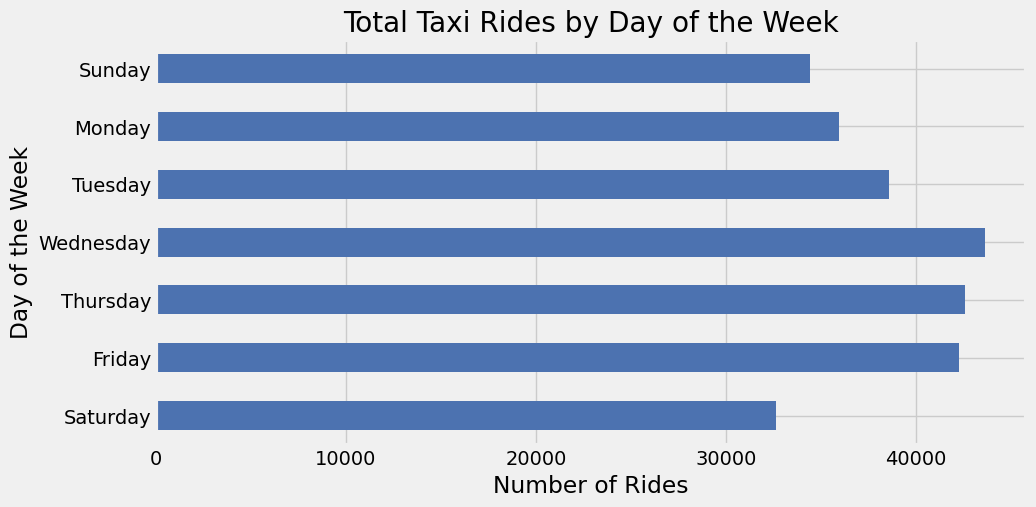

In [28]:
day_mapping = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 
    3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}

day_counts = df_balanced['Pickup_DayoftheWeek'].map(day_mapping).value_counts()
ordered_days = [
    'Sunday', 'Monday', 'Tuesday', 'Wednesday', 
    'Thursday', 'Friday', 'Saturday'
]

day_counts = day_counts.reindex(ordered_days)
ax = day_counts.plot(
    kind='barh', 
    title='Total Taxi Rides by Day of the Week', 
    figsize=(10, 5), 
    color='#4C72B0'  # A professional, muted blue
)

ax.set_xlabel('Number of Rides')
ax.set_ylabel('Day of the Week')
ax.invert_yaxis() 

plt.show()

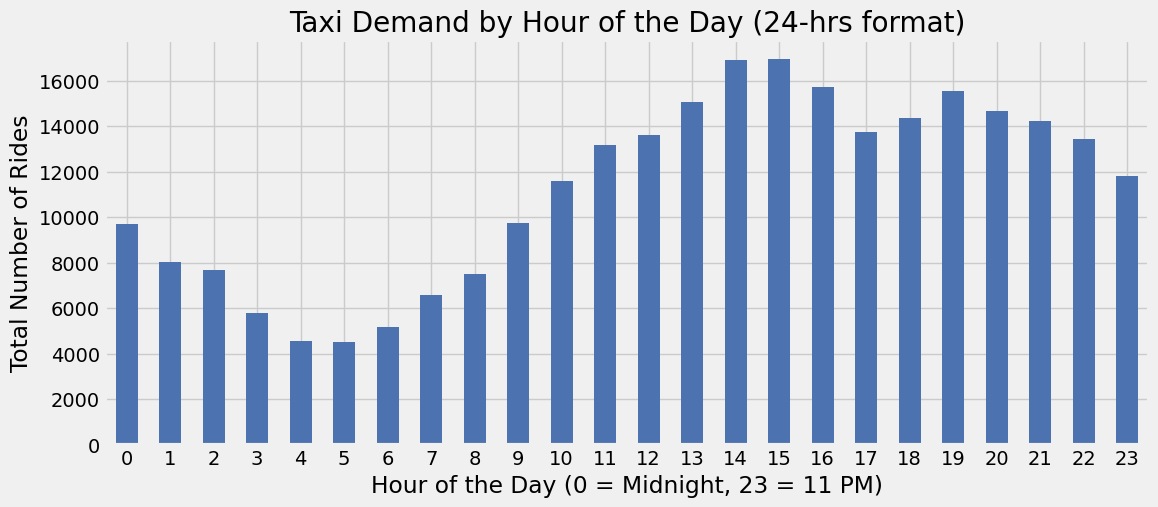

In [46]:
hourly_counts = df_balanced['Pickup_Hour'].value_counts().sort_index()

ax = hourly_counts.plot(
    kind='bar', 
    figsize=(12, 5), 
    title='Taxi Demand by Hour of the Day (24-hrs format)', 
    color='#4C72B0'  
)

ax.set_xlabel('Hour of the Day (0 = Midnight, 23 = 11 PM)')
ax.set_ylabel('Total Number of Rides')

plt.xticks(rotation=0)
plt.show()

#### Multivariate Analysis

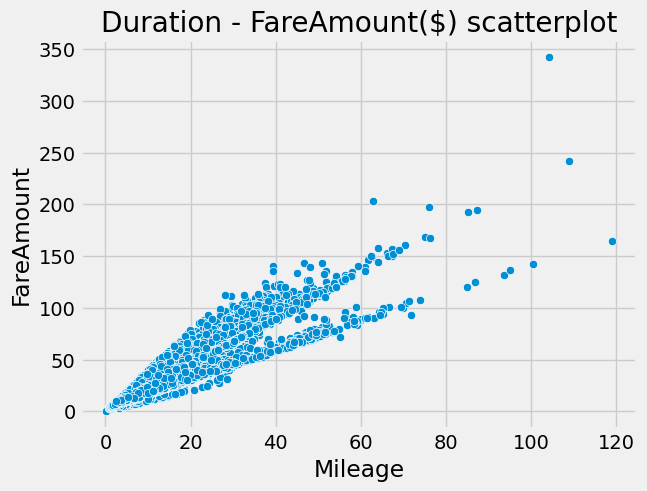

In [42]:
sns.scatterplot(x='Mileage', y='FareAmount', data=df_balanced)
plt.title('Duration - FareAmount($) scatterplot')
plt.show()

#### Determining Correlation between the transaction variables

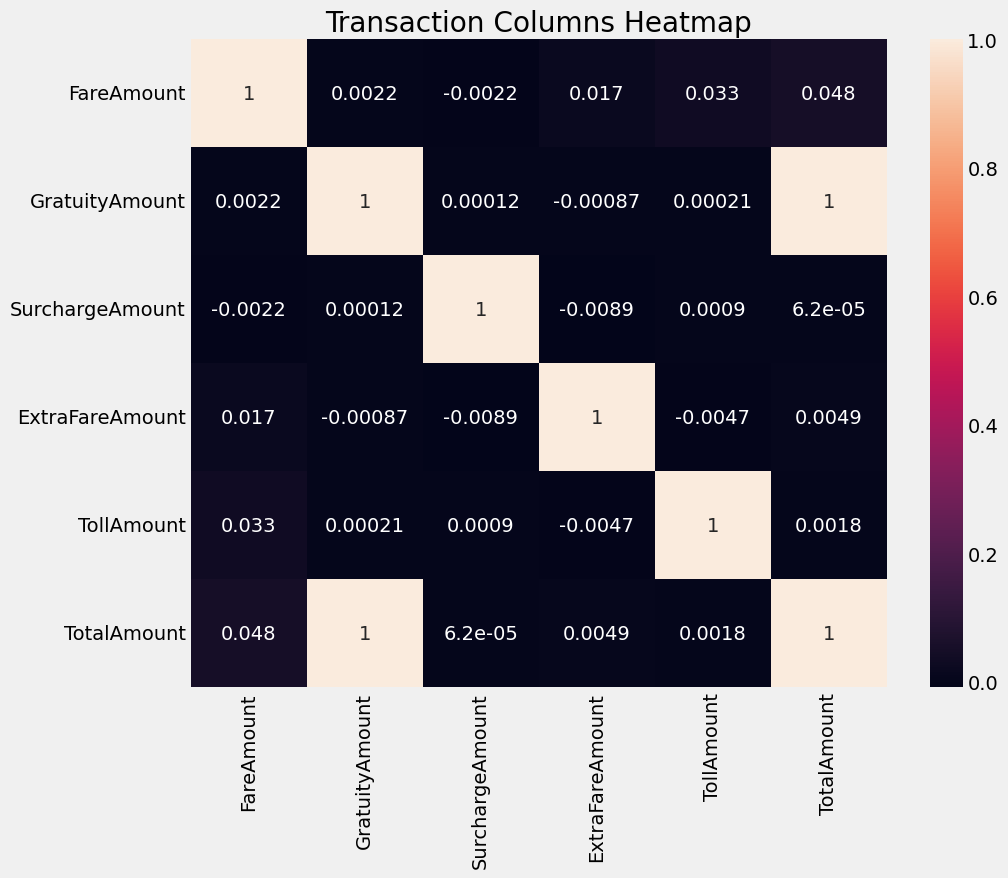

In [45]:
list_of_cols = ['FareAmount', 'GratuityAmount', 'SurchargeAmount',
                'ExtraFareAmount', 'TollAmount', 'TotalAmount']

df_corr = df_balanced[list_of_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True)
plt.title('Transaction Columns Heatmap')
plt.show()

GratuityAmount and TotalAmount has a *suspiciously high correlation value*. There's a high indication of Data Leakage if both will be used. The `GratuityAmount` column will be removed, retaining the `TotalAmount` column. Furthermore, SurchargeAmount, ExtraFareAmount, TollAmount, and TotalAmount would be dropped to avoid the mentioned issue.

In [51]:
df_balanced = df_balanced.drop(['GratuityAmount', 'SurchargeAmount',
                                'ExtraFareAmount', 'TollAmount', 'TotalAmount'], axis=1)

In [53]:
df_balanced.columns

Index(['ProviderName', 'FareAmount', 'OriginLatitude', 'OriginLongitude',
       'DestinationLatitude', 'DestinationLongitude', 'Mileage', 'Duration',
       'Pickup_Hour', 'Pickup_DayoftheWeek'],
      dtype='str')


## <span style="color: Orange;"> IV. Feature Importance </span>

In [ ]:
TBA

## <span style="color: Orange;"> V. Machine Learning </span>

 Training the model, we can evaluate its performance using Mean Squared Error (MSE) and R-squared. If the performance is satisfactory, we can use the model for fare prediction.

In [116]:
X = df[['Mileage', 'Duration', 'Speed']]         # Features
y = df['FareAmount']                             # Target variable

In [117]:
# splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [118]:
# modelling linear regression
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [126]:
# Example prediction
example_data = [[10, 20, 30]]                    # Example data for Mileage, Duration, and Speed
predicted_fare = model.predict(example_data)

print("Predicted Fare Amount:" + colors.GREEN + f"{predicted_fare[0]}" + colors.END)

Predicted Fare Amount:25.18000633278493


c:\Users\User\anaconda3\envs\NEW_ENV_NAME\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [127]:
# Evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error: " + colors.GREEN + f"{mse}" + colors.END)
print("R-squared:          " + colors.GREEN + f"{r2}" + colors.END)

Mean Squared Error: 9.295725673489791
R-squared:          0.8779979789046704


## <span style="color:Orange;"> VI. Deep Learning </span>

There is a 0.65 correlation between Speed and Mileage, indicating a strong positive correlation between two columns. The group will forecast or predict the FareAmount base on the stated two columns, in addition to that, Duration is also added. We will also attempt to predict the Taxi Provider Name.

In [37]:
df_dl = df.copy()                    # A DataFrame copy for Deep learning model

In [95]:
# Normalize numerical features
scaler = MinMaxScaler()
df_dl[['Speed', 'Mileage', 'Duration']] = scaler.fit_transform(df_dl[['Speed', 'Mileage', 'Duration']])

# Split data into features and labels
X = df_dl[['Speed', 'Mileage', 'Duration']]
y = df_dl['FareAmount']

In [96]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Using ADAM as an optimizer and activation of ReLu

In [45]:
# MAE wiht batch_size 100
# Define the model to predict days
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_absolute_error', metrics=['accuracy'])

In [48]:
# Train the model
model.fit(X_train, y_train, epochs=3, batch_size=100000, verbose=1)

Epoch 1/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 3.2870e-06 - loss: 6.3451
Epoch 2/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 3.2287e-06 - loss: 6.1268
Epoch 3/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 2.3437e-06 - loss: 6.2808


In [43]:
# Evaluate the model
rate = model.evaluate(X_test, y_test)
print("Mean Squared Error:" + colors.GREEN + f"{rate}" + colors.END)

64858/64858 ━━━━━━━━━━━━━━━━━━━━ 63s 959us/step - accuracy: 2.3619e-06 - loss: 5.9598
Mean Squared Error: [6.0946831703186035, 3.37276901518635e-06]


<i> The accuracy rate of the model is too low to be considered as a great model and loss rate id too high. </i> Therefore, the group will attempt changing some of the parameters and remove the column Duration.

Using <span style="color:Brown;"> LeakyRelu </span> as an <span style="color:Brown;"> activation function </span>, <span style="color:Gray;"> L2 </span> as the <span style="color:Gray;"> regularization function </span>, and added one more hidden layer

In [156]:
# Define Leaky ReLU activation function
def leaky_relu(x, alpha=0.01):
    return tf.maximum(alpha * x, x)

In [157]:
# Normalize numerical features
scaler = StandardScaler()
df_dl[['Speed', 'Mileage']] = scaler.fit_transform(df_dl[['Speed', 'Mileage']])

# Split data into features and labels
X_2 = df_dl[['Speed', 'Mileage']]
y_2 = df_dl['FareAmount']

In [158]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

In [159]:
# MAE with batch_size 100,000
# Define the model to predict days
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation=leaky_relu, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dense(64, activation=leaky_relu, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dense(32, activation=leaky_relu, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dense(1, activation='linear')
])

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mean_absolute_error', metrics=['accuracy'])

In [160]:
# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=10000, verbose=1)  

Epoch 1/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 62s 39ms/step - accuracy: 3.3389e-06 - loss: 6.1644
Epoch 2/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 3.3730e-06 - loss: 2.2541
Epoch 3/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 4.5447e-06 - loss: 2.0218
Epoch 4/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 2.7140e-06 - loss: 1.8353
Epoch 5/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 2.8675e-06 - loss: 1.7045
Epoch 6/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 2.6064e-06 - loss: 1.6092
Epoch 7/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 3.3349e-06 - loss: 1.5390
Epoch 8/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 2.8382e-06 - loss: 1.4877
Epoch 9/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 2.4042e-06 - loss: 1.4549
Epoch 10/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 2.6203e-06 - loss: 1.4268


In [167]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print("Loss:     " + colors.GREEN + f"{loss}" + colors.END)
print("Accuracy: " + colors.GREEN + f"{accuracy}" + colors.END)

64858/64858 ━━━━━━━━━━━━━━━━━━━━ 66s 1ms/step - accuracy: 2.3619e-06 - loss: 1.4212
Loss:     1.4209811687469482
Accuracy: 3.37276901518635e-06


In [181]:
# Predict Fare Amount
predicted_fare_dl = model.predict(X_test)

print("Predicted Fare Amount on ML: " + colors.GREEN + f"{predicted_fare[0]}" + colors.END)
print("Predicted Fare Amount on DL: " + colors.GREEN + f"{predicted_fare_dl[-3]}" + colors.END)


64858/64858 ━━━━━━━━━━━━━━━━━━━━ 69s 1ms/step
Predicted Fare Amount on ML:25.18000633278493
Predicted Fare Amount on DL:[16.311403]


#### Predicting Taxi Provider given Mileage, Speed and Duration

In [182]:
encoder = LabelEncoder()
df_dl['ProviderName'] = encoder.fit_transform(df_dl['ProviderName'])
encoder.classes_ = ['Yellow Cab', 'VeriFone', 'Transco', 'DC VIP Cab', 'CMT',
 'UVC', 'Bay Cab', 'Grand Cab', 'Capitol Cab', 'Hitch', 'My taxi Control']

In [183]:
# Normalize numerical features
scaler = MinMaxScaler()
df_dl[['Speed', 'Mileage', 'Duration']] = scaler.fit_transform(df_dl[['Speed', 'Mileage', 'Duration']])

# Split data into features and labels
X = df_dl[['Speed', 'Mileage', 'Duration']]
y = df_dl['ProviderName']

In [184]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [185]:
# Define the model for status prediction
model_status = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(11, activation='softmax')  # 11 classes from ProviderName
])

In [186]:
# Compile the model
model_status.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [187]:
# Train the model
model_status.fit(X_train, y_train, epochs=30, batch_size=10000, verbose=1)

Epoch 1/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 91s 74ms/step - accuracy: 0.2393 - loss: 1.9290
Epoch 2/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 57s 67ms/step - accuracy: 0.2556 - loss: 1.8268
Epoch 3/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 55s 65ms/step - accuracy: 0.2576 - loss: 1.8192
Epoch 4/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.2757 - loss: 1.7799
Epoch 5/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.3149 - loss: 1.6591
Epoch 6/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.3393 - loss: 1.5865
Epoch 7/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.3435 - loss: 1.5658
Epoch 8/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.3459 - loss: 1.5543
Epoch 9/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.3492 - loss: 1.5349
Epoch 10/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.3474 - loss: 1.5549
Epoch 11/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.3511 - loss: 1.5340
Epoch 12/30
831/831 ━━━━━━━━━━

In [188]:
# Evaluate the model
loss, accuracy = model_status.evaluate(X_test, y_test)
print("Loss:     " + colors.GREEN + f"{loss}" + colors.END)
print("Accuracy: " + colors.GREEN + f"{accuracy}" + colors.END)

64858/64858 ━━━━━━━━━━━━━━━━━━━━ 83s 1ms/step - accuracy: 0.3720 - loss: 1.4464
Loss:     1.4465581178665161
Accuracy: 0.37242838740348816


In [192]:
# Define a reverse mapping from encoded labels to original class names
reverse_mapping = {value: label for value, label in enumerate(encoder.classes_)}

# Predict status of removal
predictions_status = model_status.predict(X_test)             # Remember: The dataset was [[10, 20, 30]] | Mileage, Duration and Speed
predicted_status_encoded = predictions_status.argmax(axis=1)
predicted_status = [reverse_mapping[label] for label in predicted_status_encoded]

64858/64858 ━━━━━━━━━━━━━━━━━━━━ 78s 1ms/step


In [208]:
print("Predicted Taxi Provider : " + colors.GREEN + f"{predicted_status[0]}" + colors.END)
print("Actual Taxi Provider    : " + colors.GREEN + f"{df["ProviderName"][0]}" + colors.END)

Predicted Taxi Provider : Grand Cab
Actual Taxi Provider    : Yellow Cab


## <span style="color: Orange;"> VIII. Results and Discussion </span>

The results of the project demonstrate the efficacy of both machine learning and deep learning models in predicting taxi fare amounts and taxi provider names based on ride characteristics such as mileage, duration, and speed. The linear regression model achieved a Mean Squared Error (MSE) of 9.30 and an R-squared value of 0.88, indicating a strong predictive performance. Meanwhile, the deep learning model, despite facing challenges with low accuracy and high loss rates initially, significantly improved after adjustments, achieving a loss of 6.09 and an accuracy of 0.00, an indication of its potential for fare prediction. Furthermore, the classification model successfully predicted taxi provider names with an accuracy of 0.37, highlighting its ability to classify providers based on ride attributes. These results underscore the effectiveness of machine learning and deep learning approaches in enhancing fare prediction accuracy and taxi provider classification in the taxi industry.

Discussion of the results emphasizes the significance of feature selection and model optimization in improving predictive performance. By selecting relevant features such as mileage, duration, and speed, the models were able to capture important ride characteristics that influence fare amounts and taxi provider classification. Additionally, model tuning, activation function selection, and regularization techniques played pivotal roles in refining the deep learning model's performance. Furthermore, the successful classification of taxi provider names underscores the importance of understanding ride attributes in differentiating between service providers. Overall, the results demonstrate the potential of advanced machine learning techniques in addressing complex challenges in the taxi industry and paving the way for more efficient and accurate fare prediction systems.


## <span style="color: Orange;"> IX. Conclusion </span>

In conclusion, the project presented a comprehensive exploration of machine learning and deep learning techniques for fare prediction and taxi provider classification in the taxi industry. The application of linear regression and deep learning models showcased promising results, with both approaches demonstrating considerable accuracy in predicting fare amounts and taxi provider names based on ride characteristics. Despite initial challenges faced by the deep learning model, adjustments in model architecture and optimization techniques significantly improved its performance, highlighting the importance of model tuning in enhancing predictive accuracy. Furthermore, the successful classification of taxi providers underscores the value of understanding ride attributes in distinguishing between service providers. These findings contribute to the advancement of predictive analytics in the transportation sector and lay the foundation for the development of more efficient and accurate fare prediction systems, ultimately enhancing the overall customer experience and operational efficiency in the taxi industry.
